In [2]:
# ============================================================
# PHASE 5: Baseline CNN Model
# Malaria Cell Classifier — Thrive Plus Capstone
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("All libraries loaded ✅")

Device: cuda
All libraries loaded ✅


In [3]:
# Rebuild dataset (in case session restarted)
if not os.path.exists('malaria_data'):
    from google.colab import files
    print("Upload kaggle.json:")
    files.upload()
    os.makedirs('/root/.config/kaggle', exist_ok=True)
    os.system('cp kaggle.json /root/.config/kaggle/')
    os.system('chmod 600 /root/.config/kaggle/kaggle.json')
    os.system('pip install kaggle -q')
    os.system('kaggle datasets download -d iarunava/cell-images-for-detecting-malaria')
    import zipfile
    with zipfile.ZipFile('cell-images-for-detecting-malaria.zip', 'r') as zip_ref:
        zip_ref.extractall('malaria_data')

# Remove nested folder if it exists
import shutil
extra = 'malaria_data/cell_images/cell_images'
if os.path.exists(extra):
    shutil.rmtree(extra)
    print("Nested folder removed ✅")

# Transforms
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load and split
DATA_DIR = 'malaria_data/cell_images'
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transforms)

total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

torch.manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)
train_dataset.dataset.transform = train_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {train_size:,} | Val: {val_size:,} | Test: {test_size:,} ✅")
print(f"Classes: {full_dataset.classes}")

Train: 19,290 | Val: 4,133 | Test: 4,135 ✅
Classes: ['Parasitized', 'Uninfected']


In [4]:
# ============================================================
# BASELINE CNN ARCHITECTURE
# 3 Convolutional blocks + 2 Fully Connected layers
# Simple but effective for binary classification
# ============================================================

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # Block 1: Learn basic features (edges, colors)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 channels in, 32 out
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                            # 224 → 112
        )

        # Block 2: Learn complex features (shapes, textures)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                            # 112 → 56
        )

        # Block 3: Learn high-level features (parasite patterns)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                            # 56 → 28
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),                              # Prevent overfitting
            nn.Linear(256, 2)                             # 2 output classes
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# Initialize model
model = BaselineCNN().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture: BaselineCNN")
print(f"Total parameters:   {total_params:,}")
print(f"Device:             {device}")
print("\nModel structure:")
print(model)

Model architecture: BaselineCNN
Total parameters:   25,784,578
Device:             cuda

Model structure:
BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (c

In [5]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================

NUM_EPOCHS    = 10
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Fixed: removed verbose=True (not supported in newer PyTorch)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

print("Training configuration:")
print(f"  Epochs:        {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Optimizer:     Adam")
print(f"  Loss:          CrossEntropyLoss")
print(f"  Scheduler:     ReduceLROnPlateau")
print("Ready to train ✅")

Training configuration:
  Epochs:        10
  Learning rate: 0.001
  Optimizer:     Adam
  Loss:          CrossEntropyLoss
  Scheduler:     ReduceLROnPlateau
Ready to train ✅


In [6]:
# ============================================================
# TRAINING LOOP
# ============================================================

train_losses, val_losses     = [], []
train_accuracies, val_accuracies = [], []

best_val_accuracy = 0.0
best_model_path   = 'best_baseline_cnn.pth'

print("Starting training...")
print("=" * 65)

for epoch in range(NUM_EPOCHS):
    # ---- TRAINING PHASE ----
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # Clear gradients
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()                 # Backward pass
        optimizer.step()                # Update weights

        train_loss    += loss.item()
        _, predicted   = outputs.max(1)
        train_total   += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    # ---- VALIDATION PHASE ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total   += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # Compute epoch metrics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    train_acc      = 100. * train_correct / train_total
    val_acc        = 100. * val_correct   / val_total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Save best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), best_model_path)
        saved = "💾 Saved!"
    else:
        saved = ""

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% {saved}")

print("=" * 65)
print(f"Training complete ✅  Best Val Accuracy: {best_val_accuracy:.2f}%")

Starting training...
Epoch [01/10] | Train Loss: 0.9634 | Train Acc: 77.92% | Val Loss: 0.2611 | Val Acc: 91.43% 💾 Saved!
Epoch [02/10] | Train Loss: 0.3116 | Train Acc: 89.67% | Val Loss: 0.2267 | Val Acc: 93.32% 💾 Saved!
Epoch [03/10] | Train Loss: 0.2890 | Train Acc: 90.97% | Val Loss: 0.2428 | Val Acc: 92.55% 
Epoch [04/10] | Train Loss: 0.2705 | Train Acc: 91.67% | Val Loss: 0.1983 | Val Acc: 94.19% 💾 Saved!
Epoch [05/10] | Train Loss: 0.2768 | Train Acc: 91.64% | Val Loss: 0.2784 | Val Acc: 88.43% 
Epoch [06/10] | Train Loss: 0.2703 | Train Acc: 91.89% | Val Loss: 0.1780 | Val Acc: 94.58% 💾 Saved!
Epoch [07/10] | Train Loss: 0.2578 | Train Acc: 92.51% | Val Loss: 0.1885 | Val Acc: 93.71% 
Epoch [08/10] | Train Loss: 0.2418 | Train Acc: 92.61% | Val Loss: 0.1698 | Val Acc: 94.94% 💾 Saved!
Epoch [09/10] | Train Loss: 0.2423 | Train Acc: 92.87% | Val Loss: 0.1731 | Val Acc: 95.28% 💾 Saved!
Epoch [10/10] | Train Loss: 0.2108 | Train Acc: 93.41% | Val Loss: 0.1581 | Val Acc: 94.58% 
T

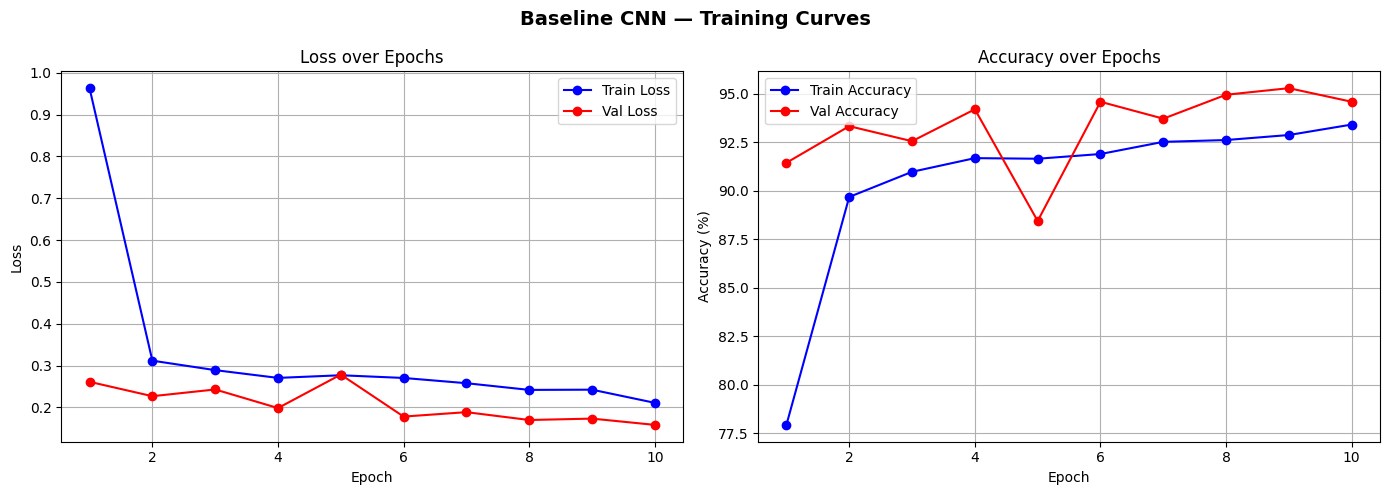

Training curves saved ✅


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline CNN — Training Curves', fontsize=14, fontweight='bold')

# Loss curve
axes[0].plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', label='Train Loss')
axes[0].plot(range(1, NUM_EPOCHS+1), val_losses,   'r-o', label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curve
axes[1].plot(range(1, NUM_EPOCHS+1), train_accuracies, 'b-o', label='Train Accuracy')
axes[1].plot(range(1, NUM_EPOCHS+1), val_accuracies,   'r-o', label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('results_baseline_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved ✅")

In [8]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
classes = ['Parasitized', 'Uninfected']
print("=" * 55)
print("   BASELINE CNN — TEST SET RESULTS")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=classes))

   BASELINE CNN — TEST SET RESULTS
              precision    recall  f1-score   support

 Parasitized       0.94      0.95      0.94      2020
  Uninfected       0.95      0.94      0.95      2115

    accuracy                           0.95      4135
   macro avg       0.95      0.95      0.95      4135
weighted avg       0.95      0.95      0.95      4135



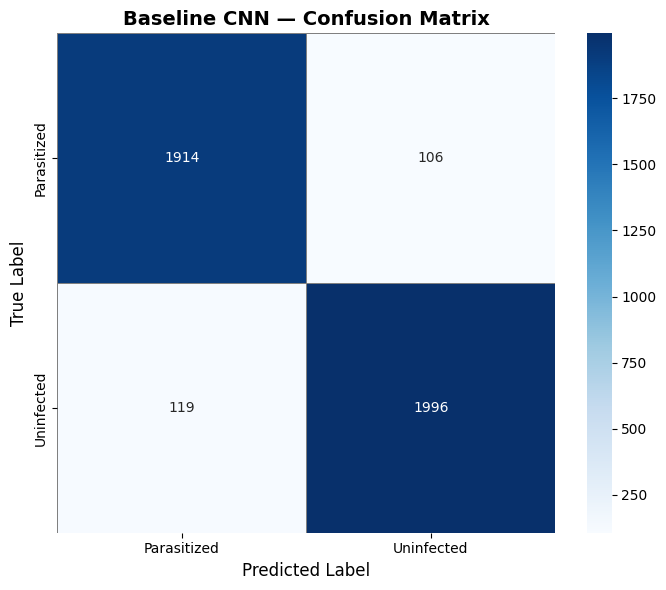


True Positives  (Infected → Infected):    1996
True Negatives  (Healthy → Healthy):      1914
False Positives (Healthy → Infected):     106  ← Healthy called Infected
False Negatives (Infected → Healthy):     119  ← DANGEROUS: Infected missed!


In [9]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray')

ax.set_title('Baseline CNN — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('results_baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpret results
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (Infected → Infected):    {tp}")
print(f"True Negatives  (Healthy → Healthy):      {tn}")
print(f"False Positives (Healthy → Infected):     {fp}  ← Healthy called Infected")
print(f"False Negatives (Infected → Healthy):     {fn}  ← DANGEROUS: Infected missed!")